Veri seti boyutu: (1030, 9)


,Cement,Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075



Eksik değerler:
Cement              0
Slag                0
Fly_Ash             0
Water               0
Superplasticizer    0
Coarse_Aggregate    0
Fine_Aggregate      0
Age                 0
Strength            0
dtype: int64


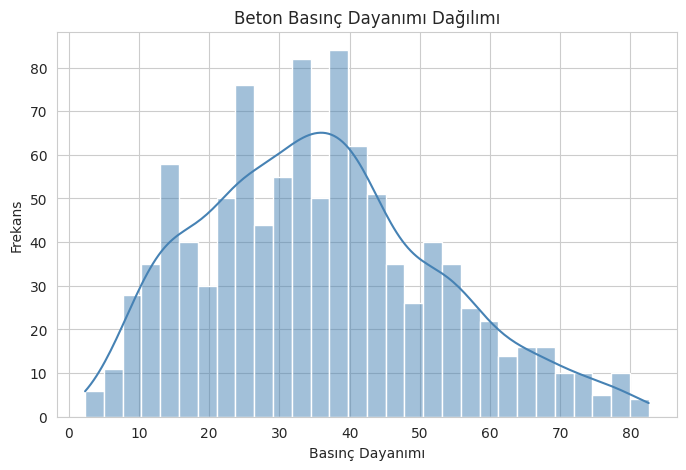

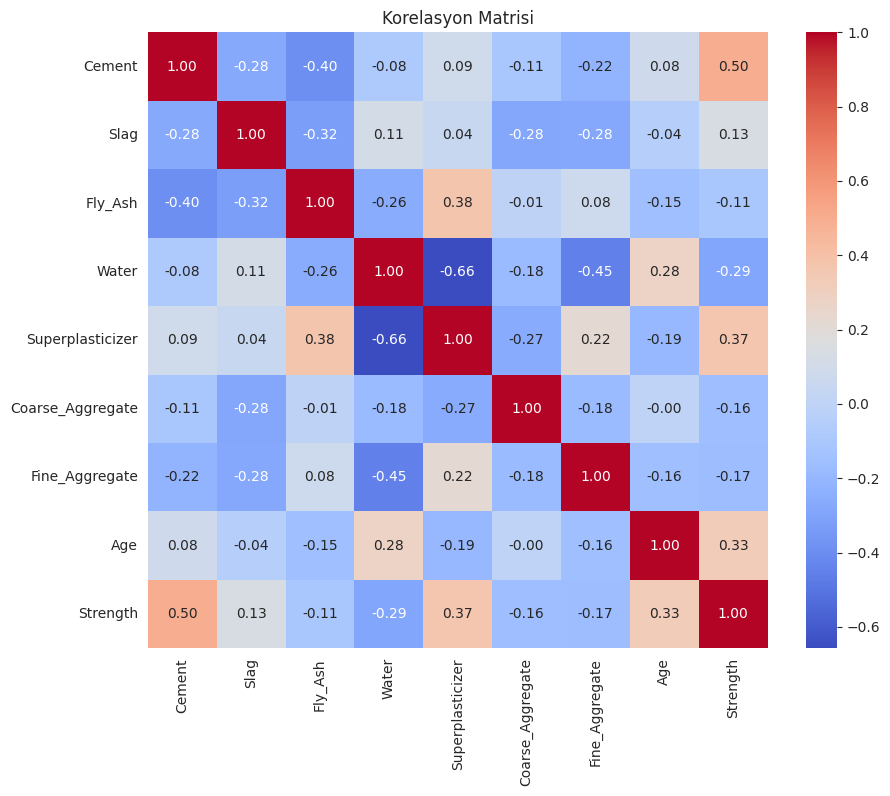

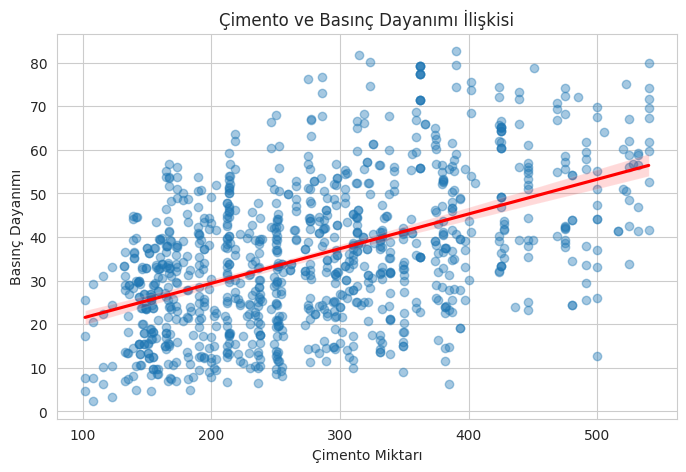

Cement-Strength korelasyonu: 0.498

LINEAR REGRESSION
R²: 0.628
MAE: 7.745
RMSE: 9.797

POLYNOMIAL REGRESSION
R²: 0.784
MAE: 5.97
RMSE: 7.456


,Model,R2,MAE,RMSE
0,Linear Regression,0.628,7.745,9.797
1,Polynomial Regression,0.784,5.970,7.456


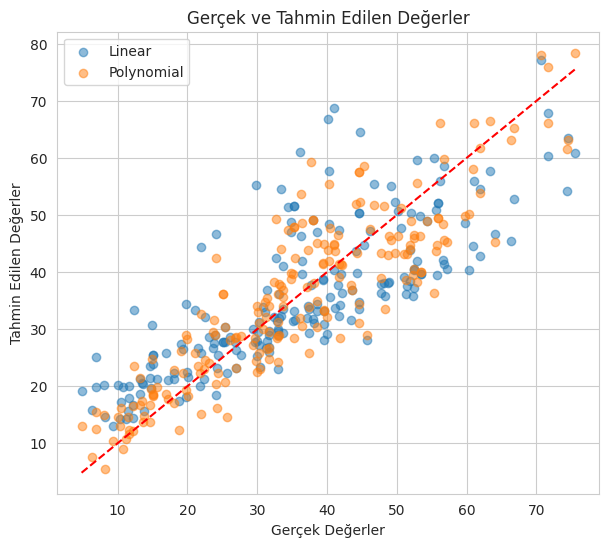

In [1]:
# Gerekli kütüphaneler
!pip install xlrd -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")


# 1. Veri setini okuma
df = pd.read_excel("Concrete_Data.xls")

# Uzun sütun isimlerini kısaltma
df.columns = [
    "Cement",
    "Slag",
    "Fly_Ash",
    "Water",
    "Superplasticizer",
    "Coarse_Aggregate",
    "Fine_Aggregate",
    "Age",
    "Strength"
]

print("Veri seti boyutu:", df.shape)
display(df.head())

print("\nEksik değerler:")
print(df.isnull().sum())


# 2. Strength dağılımı
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Strength"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Beton Basınç Dayanımı Dağılımı")
plt.xlabel("Basınç Dayanımı")
plt.ylabel("Frekans")
plt.show()


# 3. Korelasyon matrisi
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasyon Matrisi")
plt.show()


# 4. Pozitif korelasyon örneği
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Cement",
    y="Strength",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Çimento ve Basınç Dayanımı İlişkisi")
plt.xlabel("Çimento Miktarı")
plt.ylabel("Basınç Dayanımı")
plt.show()

print(
    "Cement-Strength korelasyonu:",
    round(df["Cement"].corr(df["Strength"]), 3)
)


# 5. X ve y değişkenleri
X = df.drop(columns=["Strength"])
y = df["Strength"]


# 6. Eğitim ve test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# 7. Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("\nLINEAR REGRESSION")
print("R²:", round(linear_r2, 3))
print("MAE:", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))


# 8. Polynomial Regression - 2. derece
poly_features = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_poly_train, y_train)

poly_pred = poly_model.predict(X_poly_test)

poly_r2 = r2_score(y_test, poly_pred)
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))

print("\nPOLYNOMIAL REGRESSION")
print("R²:", round(poly_r2, 3))
print("MAE:", round(poly_mae, 3))
print("RMSE:", round(poly_rmse, 3))


# 9. Modelleri karşılaştırma
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression"
    ],
    "R2": [
        linear_r2,
        poly_r2
    ],
    "MAE": [
        linear_mae,
        poly_mae
    ],
    "RMSE": [
        linear_rmse,
        poly_rmse
    ]
})

display(results.round(3))


# 10. Gerçek ve tahmin edilen değerler
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    linear_pred,
    alpha=0.5,
    label="Linear"
)

plt.scatter(
    y_test,
    poly_pred,
    alpha=0.5,
    label="Polynomial"
)

minimum = y_test.min()
maximum = y_test.max()

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--"
)

plt.title("Gerçek ve Tahmin Edilen Değerler")
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")
plt.legend()
plt.show()